# ☕ Coffee Sales Analysis

## Objective
Analyze coffee sales data to understand sales, revenue, and customer behavior.

In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
df=pd.read_csv("coffeedata.csv")
df

,date,datetime,cash_type,card,money,coffee_name
0,01-03-2024,15:50.5,card,ANON-0000-0000-0001,38.70,Latte
1,01-03-2024,19:22.5,card,ANON-0000-0000-0002,38.70,Hot Chocolate
2,01-03-2024,20:18.1,card,ANON-0000-0000-0002,38.70,Hot Chocolate
3,01-03-2024,46:33.0,card,ANON-0000-0000-0003,28.90,Americano
4,01-03-2024,48:14.6,card,ANON-0000-0000-0004,38.70,Latte
...,...,...,...,...,...,...
3631,23-03-2025,34:54.9,card,ANON-0000-0000-1158,35.76,Cappuccino
3632,23-03-2025,43:37.4,card,ANON-0000-0000-1315,35.76,Cocoa
3633,23-03-2025,44:16.9,card,ANON-0000-0000-1315,35.76,Cocoa
3634,23-03-2025,47:28.7,card,ANON-0000-0000-1316,25.96,Americano


#TOP MOST SELLING COFFEE☕☕

In [5]:
coffee_counts=df["coffee_name"].value_counts()

In [6]:
top_10=coffee_counts.head(10)
top_10

coffee_name
Americano with Milk    824
Latte                  782
Americano              578
Cappuccino             501
Cortado                292
Hot Chocolate          282
Cocoa                  243
Espresso               134
Name: count, dtype: int64

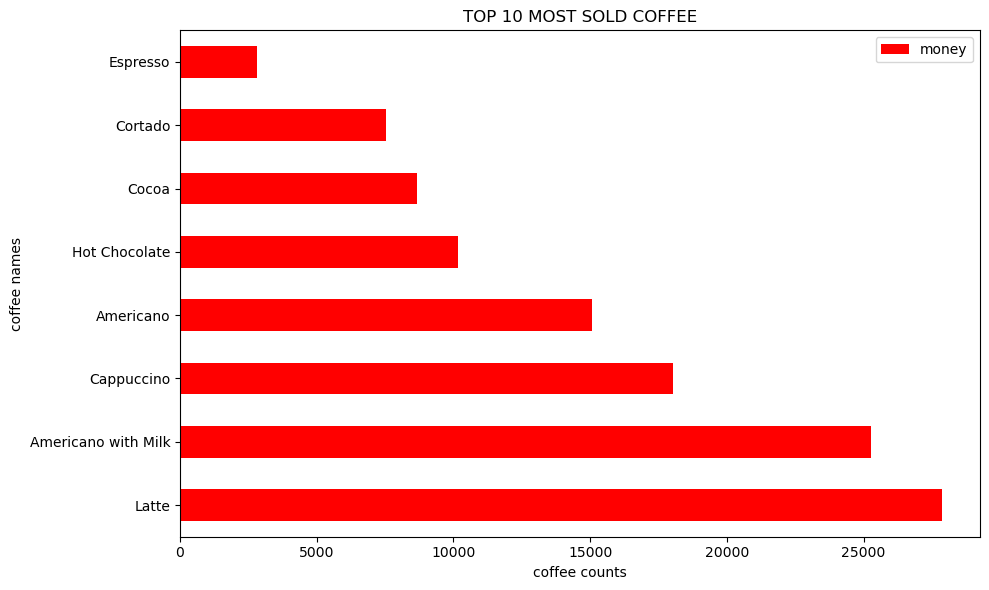

In [22]:
plt.figure(figsize=(10,6))
top_10.plot(kind='barh',color='red')

plt.title("TOP 10 MOST SOLD COFFEE")
plt.xlabel("coffee counts")
plt.ylabel("coffee names")
plt.legend()
plt.tight_layout()
plt.savefig('top_10.png')

#🟢THE MOST SELLING COFFEE IS **AMERICANO WITH MILK🥛** WITH ABOUT '824' ORDERS.
--THE SECOND TOP SELLING COFFEE IS **LATTE☕** WITH '782' ORDERS
--✨INDICATES **STRONG CUSTOMER PREFERENCE **
-- SUGGESTS THESE ITEMS HAVE TO BE **PRIORITIZED AND SHOULD BE IN TOP FOR PROMOTIONS**

In [8]:
revenue=df.groupby("coffee_name")['money'].sum()
top_10=revenue.sort_values(ascending=False).head(10)
top_10

coffee_name
Latte                  27866.30
Americano with Milk    25269.12
Cappuccino             18034.14
Americano              15062.26
Hot Chocolate          10172.46
Cocoa                   8678.16
Cortado                 7534.86
Espresso                2814.28
Name: money, dtype: float64

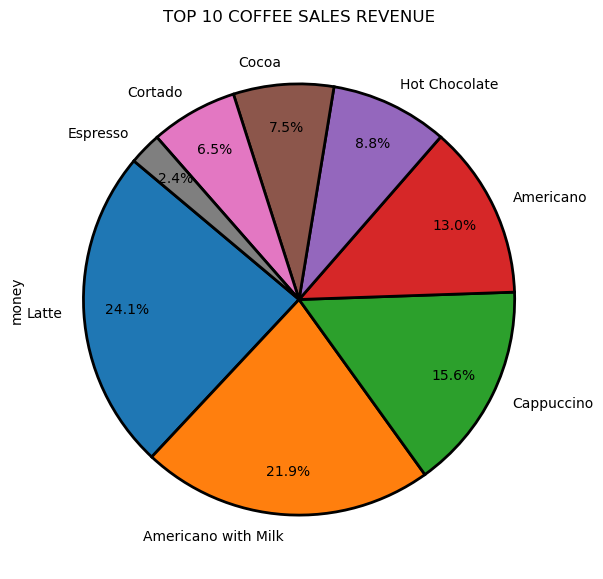

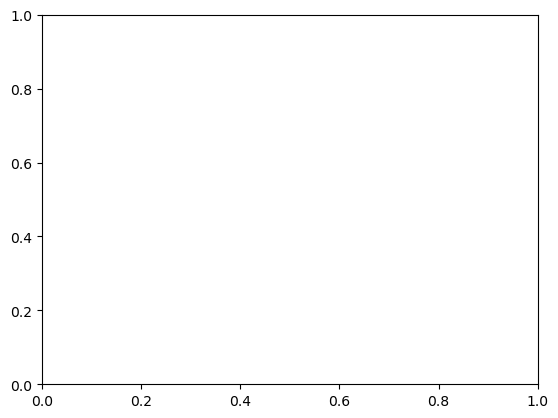

In [23]:
plt.figure(figsize=(10,7))

top_10.plot(kind='pie',autopct='%1.1f%%', startangle=140,wedgeprops={'edgecolor': 'black', 'linewidth': 2},pctdistance=0.8
)
plt.title("TOP 10 COFFEE SALES REVENUE")
plt.show()
plt.ylabel('')
plt.savefig('top_revenueS.png')

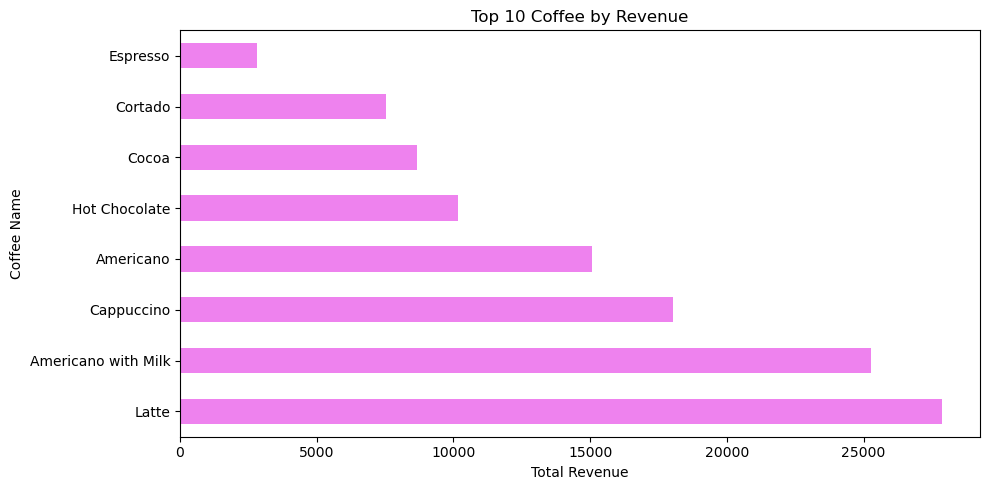

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
top_10.plot(kind='barh',color='violet')

plt.title("Top 10 Coffee by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Coffee Name")

plt.tight_layout()
plt.savefig('top10_revenue.png')


#REVENUE INSIGHTS
1.THE HIGHEST REVENUE GENERATING COFFEE IS **LATTEE WITH ABOUT '27866'**
2. THIS IS ALSO THE SECOND MOST SELLING ITEM.
3. THIS SUGGESTS **LATTEE PLAYS AN IMPORTANT ROLE IN BOTH REVENUE AND SALES**.


## ⏰ Time-Based Sales Analysis

This section analyzes how sales are distributed across time.

In [11]:
df['datetime']=df['datetime'].astype(str)
split_col=df['datetime'].str.split(':',expand=True)
minutes=split_col[0].astype(float)
seconds=split_col[1].astype(float)
df['datetime']=pd.to_timedelta(minutes*60+seconds,unit='s')


In [12]:
df['seconds']=df['datetime'].dt.total_seconds()
df['minutes']=df['datetime'].dt.total_seconds()/60
df.dtypes


date                    object
datetime       timedelta64[ns]
cash_type               object
card                    object
money                  float64
coffee_name             object
seconds                float64
minutes                float64
dtype: object

In [13]:
df['minutes']

0       15.841667
1       19.375000
2       20.301667
3       46.550000
4       48.243333
          ...    
3631    34.915000
3632    43.623333
3633    44.281667
3634    47.478333
3635    11.643333
Name: minutes, Length: 3636, dtype: float64

In [14]:
bins=[0,10,20,30,40,60]
labels=['0-10','10-20','20-30','30-40','40+']

df['time_category']=pd.cut(df['minutes'],bins=bins,labels=labels)

In [15]:
df['time_category'].value_counts().sort_index()

time_category
0-10      574
10-20     697
20-30     611
30-40     590
40+      1163
Name: count, dtype: int64

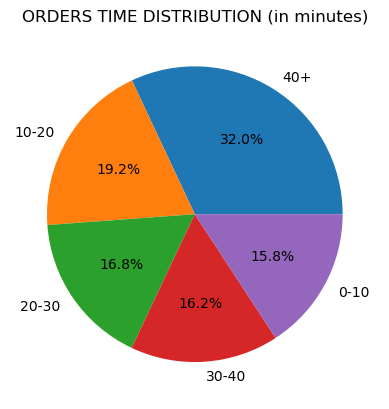

In [24]:
df['time_category'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("ORDERS TIME DISTRIBUTION (in minutes)")
plt.ylabel("")
plt.savefig('time.png')


## Insights from order distribution 
-- Majority of orders takes longer time
    **Around 32% of orders take more than 40 minutes.**
-- overall most order tend to take longer durations,with a
    noticeable number exceeding 40 minutes. This indicates     
    potential inefficiencies and scope for improving processing
    speed and consistency

## THIS SECTION SHOWS CUSTOMER CASH TYPE PREFERENCE 

In [17]:
payment_counts = df['cash_type'].value_counts()
print(payment_counts)

cash_type
card    3547
cash      89
Name: count, dtype: int64


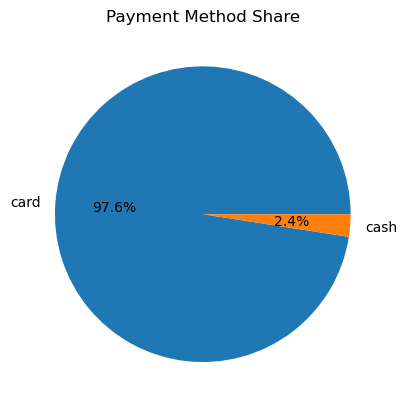

In [20]:
payment_counts.plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.title("Payment Method Share")
plt.savefig('PAYMENT METHOD.png')


## BY THIS WE CAME TO KNOW THAT AROUND 97% CUSTOMERS PREFERENCE IS **CARD.**

## FINAL INSIGHTS
🟢THE MOST POPULAR COFFEE IS **AMERICANO WITH MILK**, SHOWING STRONG CUSTOMER PREFERENCE
🟢THE HIGHEST REVENUE GENERATING COFFEE IS **LATTEE** WHICH IS ALSO THE SECOND TOP SELLING ITEM.
🟢SALES ARE CONCENTRATED IN SPECIFIC INTERVALS OF TIME, ORDERS TEND TO TAKE LONGER DURATION WITH A NUMBER EXCEEDING 40 MINUTES. 

### Business Recommendations:
🔸 Ensure high availability of top-selling products.
🔸 Focus marketing on high-revenue items.
🔸Prepare for peak demand periods with better staffing.
🔸 Optimize payment systems based on customer preference.